<a href="https://www.kaggle.com/code/sonawanelalitsunil/heart-attack-risk-prediction-in-the-u-s?scriptVersionId=224191822" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/heart-attack-prediction-in-united-states/heart_attack_dataset.csv


## Title : Heart Attack Risk Prediction in the U.S

#### Cardiovascular diseases, including heart attacks, remain a leading cause of mortality in the United States. This project aims to develop a predictive model that assesses an individual's risk of experiencing a heart attack based on key health indicators, lifestyle factors, and medical history.

**Using machine learning techniques, the model analyzes features such as age, BMI, blood pressure, cholesterol levels, diabetes status, smoking habits, physical activity, and family history of heart disease. The dataset used in this study includes real-world health records from U.S. populations, ensuring relevance and applicability in preventive healthcare.**

**The goal of this project is to provide healthcare professionals and individuals with an early warning system, enabling timely intervention and lifestyle modifications to reduce the risk of heart attacks. By leveraging data-driven insights, this predictive model can assist in personalized health recommendations and support public health initiatives aimed at cardiovascular disease prevention.**

## Import libraries

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

## Import dataset

In [3]:
df = pd.read_csv("/kaggle/input/heart-attack-prediction-in-united-states/heart_attack_dataset.csv")

In [4]:
df.head()

,Age,Gender,Cholesterol,BloodPressure,HeartRate,BMI,Smoker,Diabetes,Hypertension,FamilyHistory,...,ExerciseInducedAngina,Slope,NumberOfMajorVessels,Thalassemia,PreviousHeartAttack,StrokeHistory,Residence,EmploymentStatus,MaritalStatus,Outcome
0,31,Male,194,162,71,22.9,0,1,0,0,...,Yes,Downsloping,1,Normal,0,0,Suburban,Retired,Single,No Heart Attack
1,69,Male,208,148,93,33.9,1,1,0,0,...,Yes,Upsloping,2,Normal,0,0,Suburban,Unemployed,Married,No Heart Attack
2,34,Female,132,161,94,34.0,0,0,1,1,...,Yes,Upsloping,0,Normal,1,0,Rural,Retired,Single,Heart Attack
3,53,Male,268,134,91,35.0,0,1,1,0,...,Yes,Flat,0,Reversible defect,1,0,Suburban,Retired,Widowed,No Heart Attack
4,57,Female,203,140,75,30.1,0,1,0,0,...,Yes,Flat,0,Fixed defect,1,0,Rural,Retired,Married,Heart Attack


In [5]:
df.tail()

,Age,Gender,Cholesterol,BloodPressure,HeartRate,BMI,Smoker,Diabetes,Hypertension,FamilyHistory,...,ExerciseInducedAngina,Slope,NumberOfMajorVessels,Thalassemia,PreviousHeartAttack,StrokeHistory,Residence,EmploymentStatus,MaritalStatus,Outcome
372969,49,Female,285,131,79,27.6,0,1,1,1,...,Yes,Flat,2,Fixed defect,1,0,Urban,Employed,Married,No Heart Attack
372970,77,Male,197,159,64,33.5,0,1,0,1,...,No,Downsloping,3,Fixed defect,0,1,Urban,Employed,Married,Heart Attack
372971,53,Female,243,94,84,34.7,1,1,1,0,...,Yes,Flat,3,Reversible defect,1,1,Urban,Retired,Married,Heart Attack
372972,78,Female,291,93,78,29.3,1,1,0,1,...,Yes,Upsloping,1,Fixed defect,0,0,Urban,Employed,Married,No Heart Attack
372973,71,Male,127,153,83,39.7,1,1,1,0,...,No,Upsloping,3,Fixed defect,1,1,Urban,Unemployed,Single,Heart Attack


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 372974 entries, 0 to 372973
Data columns (total 32 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   Age                    372974 non-null  int64  
 1   Gender                 372974 non-null  object 
 2   Cholesterol            372974 non-null  int64  
 3   BloodPressure          372974 non-null  int64  
 4   HeartRate              372974 non-null  int64  
 5   BMI                    372974 non-null  float64
 6   Smoker                 372974 non-null  int64  
 7   Diabetes               372974 non-null  int64  
 8   Hypertension           372974 non-null  int64  
 9   FamilyHistory          372974 non-null  int64  
 10  PhysicalActivity       372974 non-null  int64  
 11  AlcoholConsumption     372974 non-null  int64  
 12  Diet                   372974 non-null  object 
 13  StressLevel            372974 non-null  int64  
 14  Ethnicity              372974 non-nu

In [7]:
df.describe()

,Age,Cholesterol,BloodPressure,HeartRate,BMI,Smoker,Diabetes,Hypertension,FamilyHistory,PhysicalActivity,AlcoholConsumption,StressLevel,Income,MaxHeartRate,ST_Depression,NumberOfMajorVessels,PreviousHeartAttack,StrokeHistory
count,372974.000000,372974.000000,372974.000000,372974.000000,372974.000000,372974.000000,372974.000000,372974.000000,372974.000000,372974.000000,372974.000000,372974.000000,372974.000000,372974.000000,372974.000000,372974.000000,372974.000000,372974.000000
mean,56.975151,199.455844,134.508234,89.495043,29.006733,0.499225,0.500987,0.500973,0.499901,3.003475,2.000048,5.001885,110033.409913,149.463896,2.501799,1.498525,0.496938,0.500815
std,15.867016,57.723381,25.984528,17.342658,6.345460,0.500000,0.500000,0.500000,0.500001,2.000114,1.414572,2.582025,51961.721991,28.849990,1.443696,1.118003,0.499991,0.500000
min,30.000000,100.000000,90.000000,60.000000,18.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,20000.000000,100.000000,0.000000,0.000000,0.000000,0.000000
25%,43.000000,149.000000,112.000000,74.000000,23.500000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,3.000000,64957.250000,124.000000,1.250000,0.000000,0.000000,0.000000
50%,57.000000,199.000000,134.000000,89.000000,29.000000,0.000000,1.000000,1.000000,0.000000,3.000000,2.000000,5.000000,110111.000000,149.000000,2.500000,1.000000,0.000000,1.000000
75%,71.000000,249.000000,157.000000,105.000000,34.500000,1.000000,1.000000,1.000000,1.000000,5.000000,3.000000,7.000000,155012.000000,174.000000,3.750000,2.000000,1.000000,1.000000
max,84.000000,299.000000,179.000000,119.000000,40.000000,1.000000,1.000000,1.000000,1.000000,6.000000,4.000000,9.000000,199999.000000,199.000000,5.000000,3.000000,1.000000,1.000000


In [8]:
df.isnull().sum()

Age                      0
Gender                   0
Cholesterol              0
BloodPressure            0
HeartRate                0
BMI                      0
Smoker                   0
Diabetes                 0
Hypertension             0
FamilyHistory            0
PhysicalActivity         0
AlcoholConsumption       0
Diet                     0
StressLevel              0
Ethnicity                0
Income                   0
EducationLevel           0
Medication               0
ChestPainType            0
ECGResults               0
MaxHeartRate             0
ST_Depression            0
ExerciseInducedAngina    0
Slope                    0
NumberOfMajorVessels     0
Thalassemia              0
PreviousHeartAttack      0
StrokeHistory            0
Residence                0
EmploymentStatus         0
MaritalStatus            0
Outcome                  0
dtype: int64

In [9]:
df.dtypes

Age                        int64
Gender                    object
Cholesterol                int64
BloodPressure              int64
HeartRate                  int64
BMI                      float64
Smoker                     int64
Diabetes                   int64
Hypertension               int64
FamilyHistory              int64
PhysicalActivity           int64
AlcoholConsumption         int64
Diet                      object
StressLevel                int64
Ethnicity                 object
Income                     int64
EducationLevel            object
Medication                object
ChestPainType             object
ECGResults                object
MaxHeartRate               int64
ST_Depression            float64
ExerciseInducedAngina     object
Slope                     object
NumberOfMajorVessels       int64
Thalassemia               object
PreviousHeartAttack        int64
StrokeHistory              int64
Residence                 object
EmploymentStatus          object
MaritalSta

In [10]:
df.duplicated()

0         False
1         False
2         False
3         False
4         False
          ...  
372969    False
372970    False
372971    False
372972    False
372973    False
Length: 372974, dtype: bool

In [11]:
df.columns

Index(['Age', 'Gender', 'Cholesterol', 'BloodPressure', 'HeartRate', 'BMI',
       'Smoker', 'Diabetes', 'Hypertension', 'FamilyHistory',
       'PhysicalActivity', 'AlcoholConsumption', 'Diet', 'StressLevel',
       'Ethnicity', 'Income', 'EducationLevel', 'Medication', 'ChestPainType',
       'ECGResults', 'MaxHeartRate', 'ST_Depression', 'ExerciseInducedAngina',
       'Slope', 'NumberOfMajorVessels', 'Thalassemia', 'PreviousHeartAttack',
       'StrokeHistory', 'Residence', 'EmploymentStatus', 'MaritalStatus',
       'Outcome'],
      dtype='object')

In [12]:
from sklearn.preprocessing import LabelEncoder,StandardScaler

obj_cols = df.select_dtypes(include=['object']).columns
label_encoders = {}
for col in obj_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le 

In [13]:
df.corr()

,Age,Gender,Cholesterol,BloodPressure,HeartRate,BMI,Smoker,Diabetes,Hypertension,FamilyHistory,...,ExerciseInducedAngina,Slope,NumberOfMajorVessels,Thalassemia,PreviousHeartAttack,StrokeHistory,Residence,EmploymentStatus,MaritalStatus,Outcome
Age,1.000000,-0.001107,0.004333,0.000662,-0.003064,0.000928,-0.001535,0.000910,-0.000724,8.263232e-04,...,-0.001243,-0.002099,0.001174,0.000327,0.001014,0.001782,0.001881,0.002282,-0.002199,0.000947
Gender,-0.001107,1.000000,-0.000731,-0.003038,0.001799,0.002980,0.001348,0.001477,0.000571,1.238995e-03,...,-0.002338,0.002870,-0.001423,-0.002336,-0.000677,0.002003,0.000742,-0.001314,0.000826,0.001892
Cholesterol,0.004333,-0.000731,1.000000,0.003120,0.002186,0.003879,-0.001386,0.001099,-0.001604,-1.822831e-03,...,-0.002812,-0.001953,0.002091,-0.000312,0.001563,-0.002497,-0.002450,-0.001339,-0.000537,0.001962
BloodPressure,0.000662,-0.003038,0.003120,1.000000,0.000545,-0.001592,0.002798,0.000714,0.001351,-9.447818e-04,...,0.002276,0.000710,0.000615,-0.000954,0.002024,-0.002837,-0.000194,-0.001685,0.002284,-0.000496
HeartRate,-0.003064,0.001799,0.002186,0.000545,1.000000,0.000250,0.003537,0.000185,0.000059,5.303721e-04,...,-0.000624,0.000664,-0.000799,0.002739,0.001324,0.000142,0.000832,0.001999,-0.000345,0.001471
BMI,0.000928,0.002980,0.003879,-0.001592,0.000250,1.000000,0.000547,-0.000206,-0.003841,1.280227e-03,...,0.001594,0.000857,-0.000458,-0.000582,0.000786,0.002550,-0.001215,-0.000298,0.000003,-0.000403
Smoker,-0.001535,0.001348,-0.001386,0.002798,0.003537,0.000547,1.000000,-0.000480,-0.002855,-2.279289e-03,...,0.000815,-0.000103,0.001111,0.001245,0.000420,0.003145,-0.001767,-0.001812,0.000565,-0.000830
Diabetes,0.000910,0.001477,0.001099,0.000714,0.000185,-0.000206,-0.000480,1.000000,-0.000133,1.416043e-03,...,-0.002386,-0.001283,0.001218,-0.000133,0.000168,-0.003526,0.000394,0.000924,-0.000976,-0.000710
Hypertension,-0.000724,0.000571,-0.001604,0.001351,0.000059,-0.003841,-0.002855,-0.000133,1.000000,-4.125120e-04,...,-0.001448,-0.000068,-0.000127,-0.000627,-0.001822,-0.002706,0.002642,-0.000495,0.000058,-0.000318
FamilyHistory,0.000826,0.001239,-0.001823,-0.000945,0.000530,0.001280,-0.002279,0.001416,-0.000413,1.000000e+00,...,-0.000043,0.001728,0.000758,0.000283,0.000106,0.000998,-0.000470,0.001423,0.001338,-0.000413


## Data visulization 

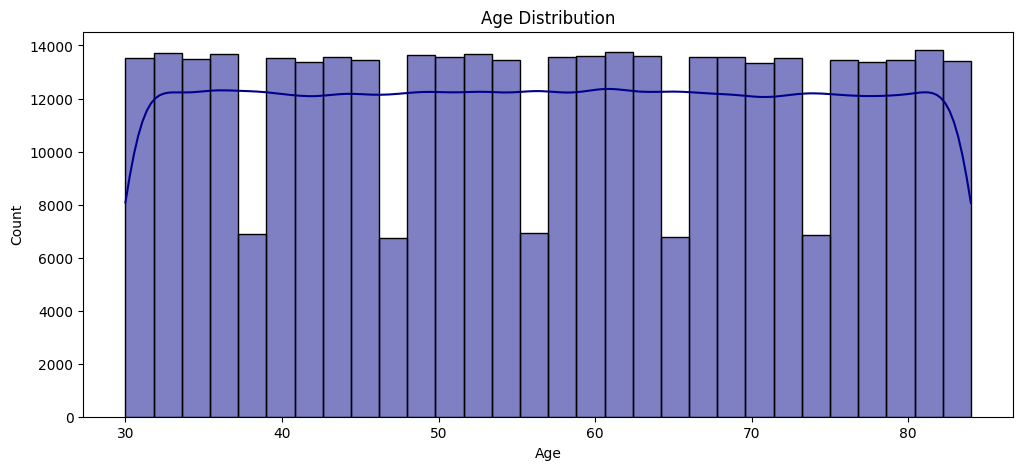

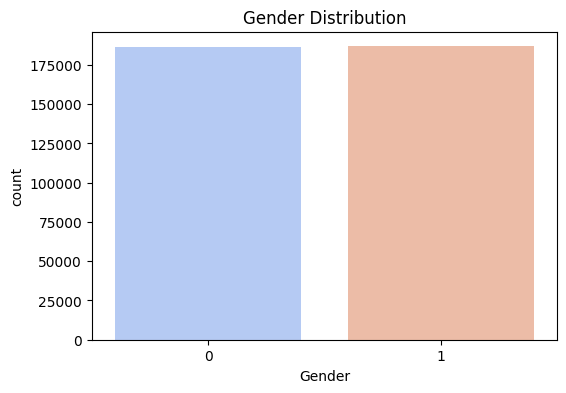

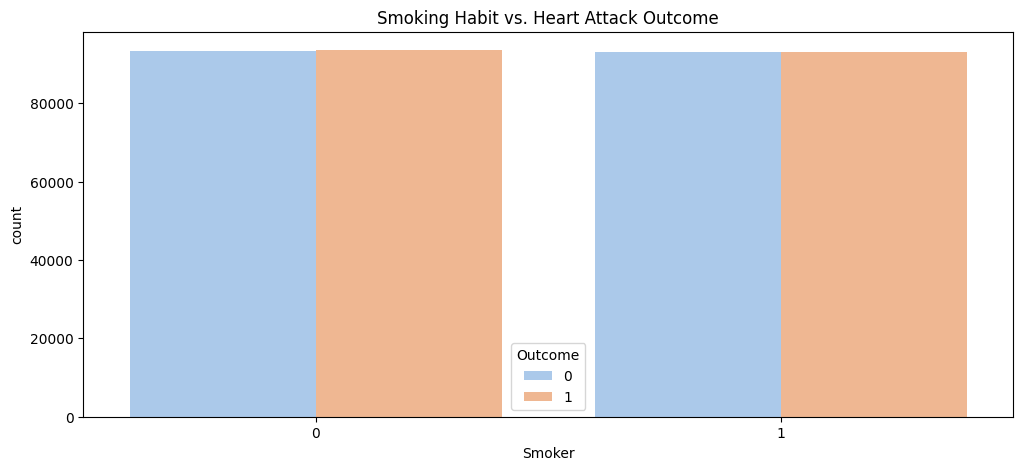

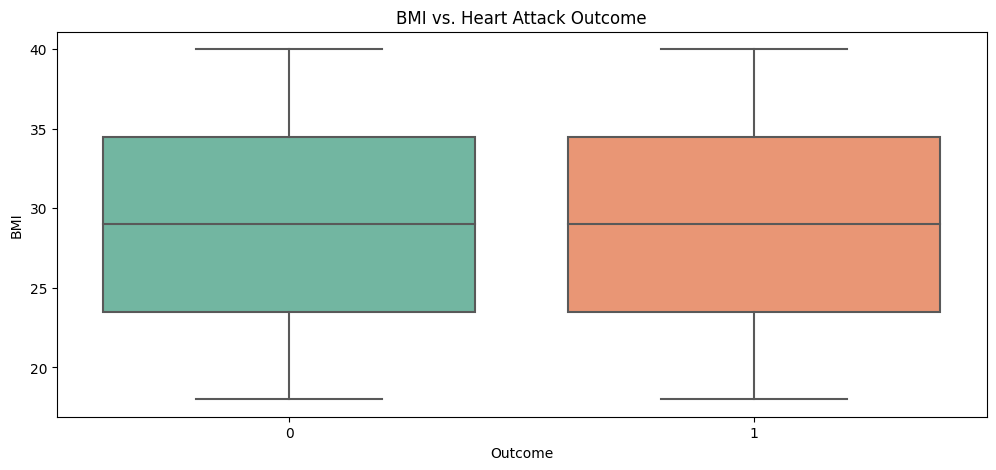

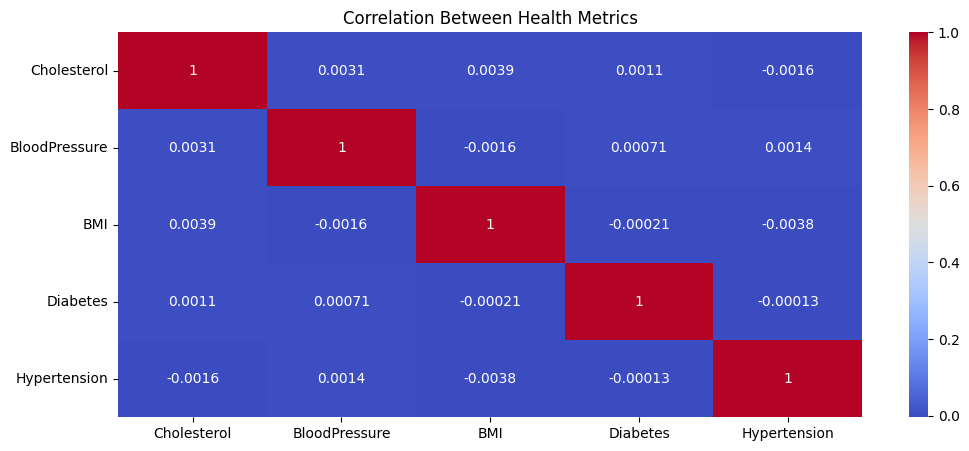

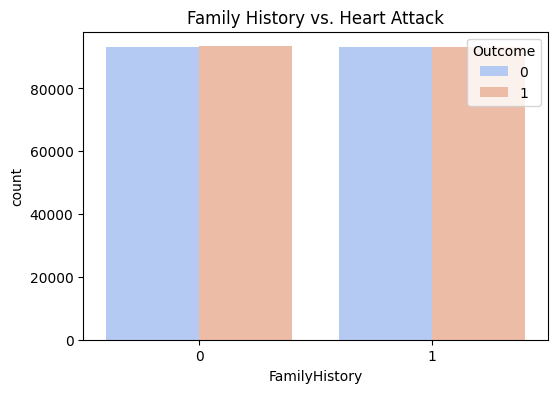

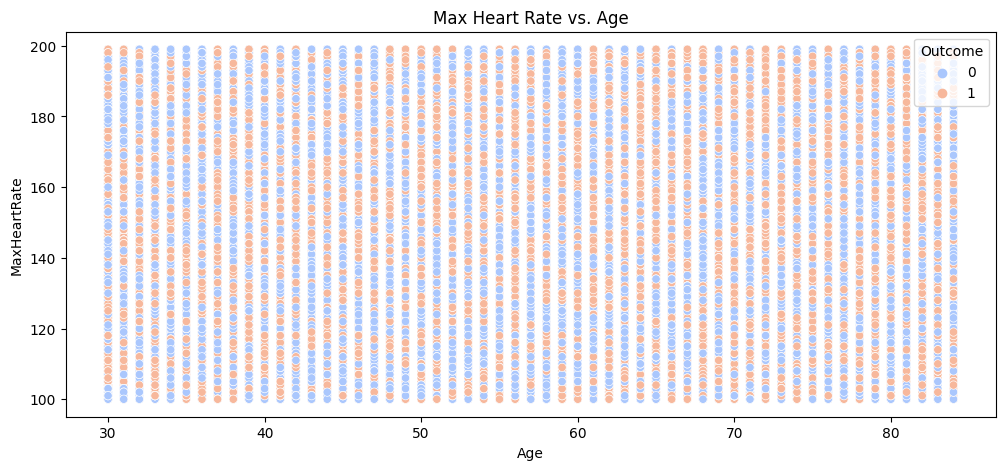

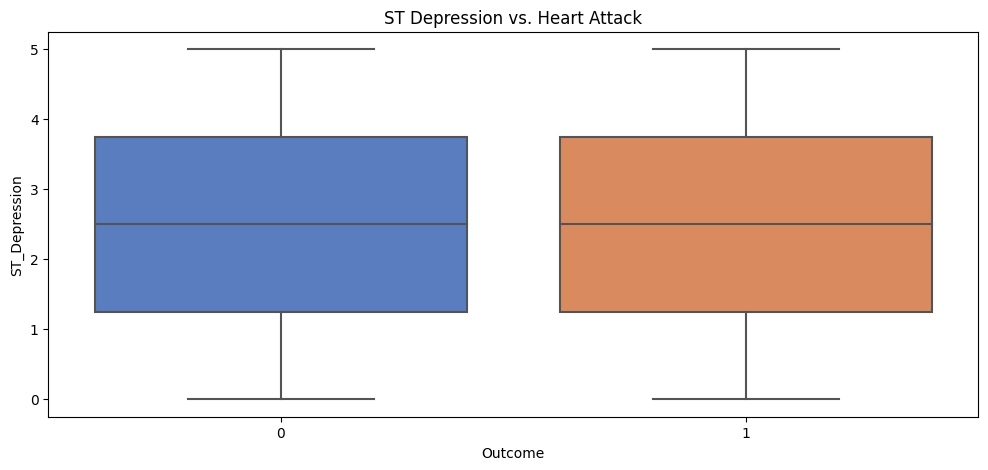

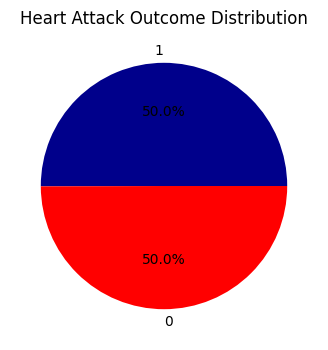

In [14]:
plt.figure(figsize=(12, 5))

# Histogram of Age
sns.histplot(df["Age"], bins=30, kde=True, color="darkblue")
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

# Gender Count
plt.figure(figsize=(6, 4))
sns.countplot(x="Gender", data=df, palette="coolwarm")
plt.title("Gender Distribution")
plt.show()

### 2. Lifestyle Factors ###
plt.figure(figsize=(12, 5))
sns.countplot(x="Smoker", hue="Outcome", data=df, palette="pastel")
plt.title("Smoking Habit vs. Heart Attack Outcome")
plt.show()

plt.figure(figsize=(12, 5))
sns.boxplot(x="Outcome", y="BMI", data=df, palette="Set2")
plt.title("BMI vs. Heart Attack Outcome")
plt.show()

### 3. Medical History ###
plt.figure(figsize=(12, 5))
sns.heatmap(df[["Cholesterol", "BloodPressure", "BMI", "Diabetes", "Hypertension"]].corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Between Health Metrics")
plt.show()

# Family History & Outcome
plt.figure(figsize=(6, 4))
sns.countplot(x="FamilyHistory", hue="Outcome", data=df, palette="coolwarm")
plt.title("Family History vs. Heart Attack")
plt.show()

### 4. Exercise & Cardiac Health ###
plt.figure(figsize=(12, 5))
sns.scatterplot(x="Age", y="MaxHeartRate", hue="Outcome", data=df, palette="coolwarm")
plt.title("Max Heart Rate vs. Age")
plt.show()

plt.figure(figsize=(12, 5))
sns.boxplot(x="Outcome", y="ST_Depression", data=df, palette="muted")
plt.title("ST Depression vs. Heart Attack")
plt.show()

### 5. Outcome Distribution ###
plt.figure(figsize=(6, 4))
df["Outcome"].value_counts().plot(kind="pie", autopct="%1.1f%%", colors=["darkblue", "red"])
plt.title("Heart Attack Outcome Distribution")
plt.ylabel("")
plt.show()

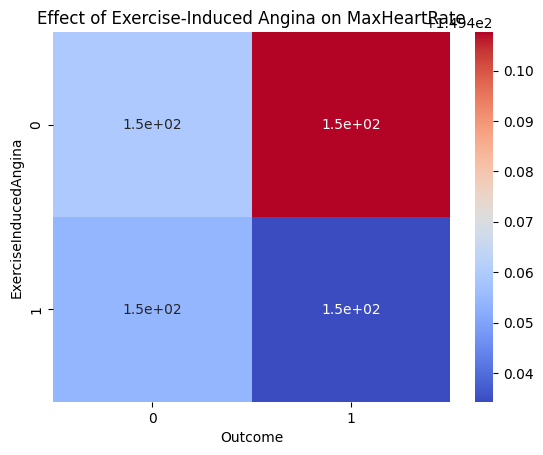

In [15]:
pivot_table = df.pivot_table(values="MaxHeartRate", index="ExerciseInducedAngina", columns="Outcome", aggfunc='mean')
sns.heatmap(pivot_table, annot=True, cmap="coolwarm")
plt.title("Effect of Exercise-Induced Angina on MaxHeartRate")
plt.show()

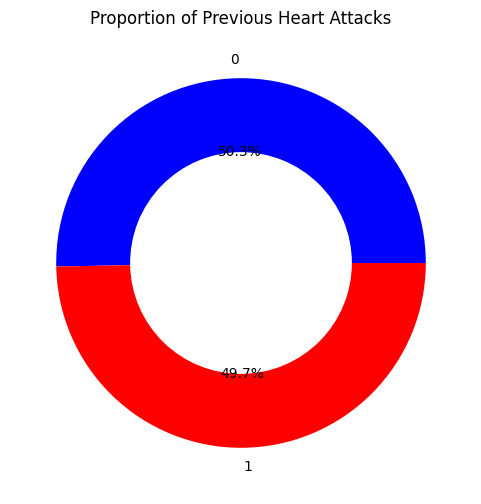

In [16]:
plt.figure(figsize=(6, 6))
df["PreviousHeartAttack"].value_counts().plot(kind="pie", autopct="%1.1f%%", colors=["blue", "red"], wedgeprops=dict(width=0.4))
plt.title("Proportion of Previous Heart Attacks")
plt.ylabel("")
plt.show()

## Feature Engineering

In [17]:
x=df.drop(["Outcome"],axis=1)
y=df["Outcome"]

In [18]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.25,random_state=42)
ss=StandardScaler()

In [19]:
x_train=ss.fit_transform(x_train)
x_test=ss.transform(x_test)

In [20]:
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB

In [21]:
models={
    "Random Forest Classifier":RandomForestClassifier(),
    "Decision Tree Classifier":DecisionTreeClassifier(),
    "Ada Boost Classifier":AdaBoostClassifier(),
    "Logistic Regression":LogisticRegression(),
    "Gradiant Boosting Classifier":GradientBoostingClassifier(),
    "Naive Bayes Classifier":GaussianNB()
}

In [22]:
metrics = {
    'Model': [],
    'Accuracy': [],
    'Precision': [],
    'Recall':[]
}

In [23]:

from sklearn.metrics import accuracy_score, f1_score, recall_score, precision_score, confusion_matrix, classification_report

for name, model in models.items():
    model.fit(x_train, y_train)  # Train the model
    y_pred = model.predict(x_test)  # Predict on test data

    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)

    print(f"Model: {name}")
    print(f"Accuracy: {acc:.4f}, F1 Score: {f1:.4f}, Recall: {recall:.4f}, Precision: {precision:.4f}")
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
    print("Classification Report:\n", classification_report(y_test, y_pred))
    print("-" * 50)

Model: Random Forest Classifier
Accuracy: 0.4996, F1 Score: 0.4805, Recall: 0.4604, Precision: 0.5023
Confusion Matrix:
 [[25007 21376]
 [25285 21576]]
Classification Report:
               precision    recall  f1-score   support

           0       0.50      0.54      0.52     46383
           1       0.50      0.46      0.48     46861

    accuracy                           0.50     93244
   macro avg       0.50      0.50      0.50     93244
weighted avg       0.50      0.50      0.50     93244

--------------------------------------------------
Model: Decision Tree Classifier
Accuracy: 0.5002, F1 Score: 0.5010, Recall: 0.4993, Precision: 0.5027
Confusion Matrix:
 [[23239 23144]
 [23462 23399]]
Classification Report:
               precision    recall  f1-score   support

           0       0.50      0.50      0.50     46383
           1       0.50      0.50      0.50     46861

    accuracy                           0.50     93244
   macro avg       0.50      0.50      0.50     9324

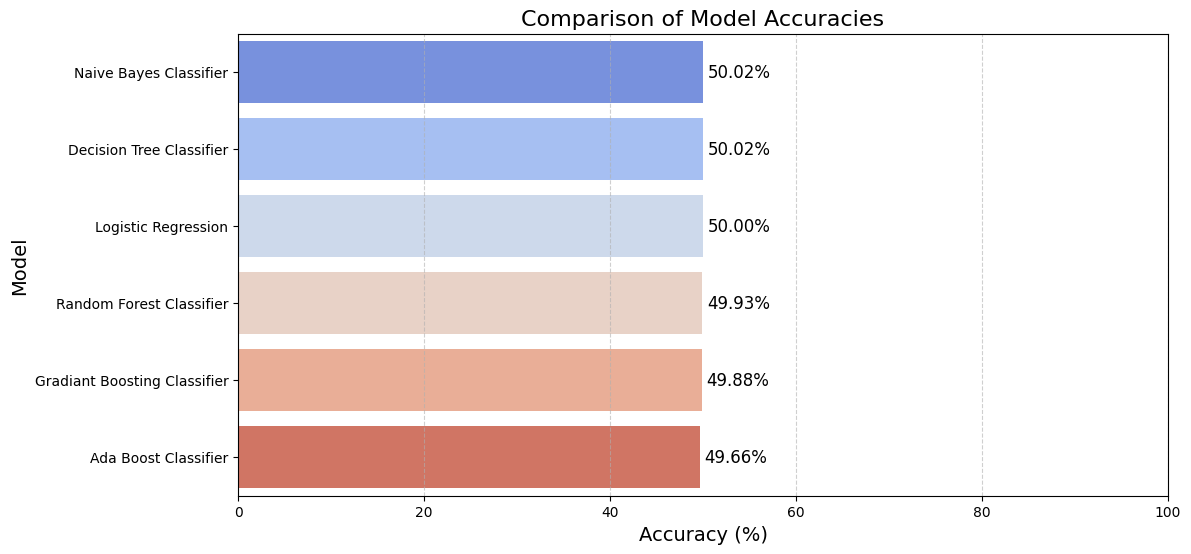

In [24]:
from sklearn.metrics import accuracy_score

model_accuracies = {}

for name, model in models.items():
    model.fit(x_train, y_train) 
    y_pred = model.predict(x_test)  
    
    acc = accuracy_score(y_test, y_pred)  
    model_accuracies[name] = acc * 100  

acc_df = pd.DataFrame(model_accuracies.items(), columns=['Model', 'Accuracy'])

# Sort values for better visualization
acc_df = acc_df.sort_values(by='Accuracy', ascending=False)

# 🔹 Bar Plot for Accuracy
plt.figure(figsize=(12, 6))
sns.barplot(x="Accuracy", y="Model", data=acc_df, palette="coolwarm")

for index, value in enumerate(acc_df["Accuracy"]):
    plt.text(value + 0.5, index, f"{value:.2f}%", va='center', fontsize=12)

plt.xlabel("Accuracy (%)", fontsize=14)
plt.ylabel("Model", fontsize=14)
plt.title("Comparison of Model Accuracies", fontsize=16)
plt.xlim(0, 100)
plt.grid(axis="x", linestyle="--", alpha=0.6)
plt.show()

## Thank you...pls upvote...!!!!